# Feature Engineeirng
1 question = many user-plane rows + many engineering rows.  

1 answer = target class

| Feature Group        | Fields Created                                                                                                                                                                            | Related Root Cause |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------ |
| Throughput           | `avg_throughput`, `min_throughput`, `std_throughput`, `low_tp_count`, `low_tp_ratio`, `avg_throughput_low_tp`, `consecutive_low_tp_max`                                                   | All                |
| Speed                | `max_speed`, `pct_speed_above_40`, `avg_speed_low_tp`, `max_speed_low_tp`                                                                                                                 | C7                 |
| Handover             | `num_unique_serving_pci`, `handover_count`, `handover_rate`, `handover_count_low_tp`                                                                                                      | C5                 |
| RSRP/SINR            | `avg_rsrp`, `min_rsrp`, `avg_rsrp_low_tp`, `avg_sinr`, `min_sinr`, `avg_sinr_low_tp`                                                                                                      | C1, C2, C4, C6     |
| RB                   | `avg_rb`, `min_rb`, `avg_rb_low_tp`, `min_rb_low_tp`, `pct_rb_below_160`                                                                                                                  | C8                 |
| Neighbor             | `avg_neighbor_advantage`, `max_neighbor_advantage`, `neighbor_stronger_ratio`, `avg_close_neighbor_count`, `overlap_ratio`                                                                | C3, C4             |
| PCI Mod 30           | `same_mod30_exists`, `same_mod30_count`, `same_mod30_ratio`                                                                                                                               | C6                 |
| Engineering/Distance | `avg_serving_tilt`, `max_serving_tilt`, `avg_serving_beamwidth`, `avg_serving_height`, `avg_serving_distance_km`, `max_serving_distance_km`, `pct_distance_gt_1km`, `avg_distance_low_tp` |                    |


## Load the library

In [1]:
import json
import re
import math
import numpy as np
import pandas as pd
from io import StringIO

## Parse embedded tables

In [4]:
def parse_tables(question):
    text = question.replace("\r\n", "\n").replace("\r", "\n")

    user_match = re.search(
        r"User plane drive test data as follows[：:]\s*\n+(.*?)(?:\n\s*\n\s*Engeneering parameters data as follows[：:]|\n\s*\n\s*Engineering parameters data as follows[：:])",
        text,
        flags=re.S
    )

    eng_match = re.search(
        r"(?:Engeneering|Engineering) parameters data as follows[：:]\s*\n+(.*)$",
        text,
        flags=re.S
    )

    if not user_match or not eng_match:
        raise ValueError("Could not find table blocks")

    def block_to_df(block):
        lines = []
        for line in block.splitlines():
            line = line.strip()
            if "|" in line:
                lines.append(line)

        # Repairs rare formatting issue like "g\nNodeB ID"
        if lines and lines[0].startswith("NodeB ID|"):
            lines[0] = "g" + lines[0]

        return pd.read_csv(StringIO("\n".join(lines)), sep="|")

    user_df = block_to_df(user_match.group(1))
    eng_df = block_to_df(eng_match.group(1))

    return user_df, eng_df

## Helper functions

In [ ]:
def beamwidth_from_scenario(s):
    if pd.isna(s):
        return np.nan

    s = str(s).upper()

    if "DEFAULT" in s:
        return 6

    match = re.search(r"SCENARIO_(\d+)", s)
    if match:
        n = int(match.group(1))
        if n <= 5:
            return 6
        elif n <= 11:
            return 12
        else:
            return 25

    return np.nan

# Calculate distance between vehicle GPS location and tower location
# C2: coverage distance exceeds 1 km -> To calculate distance
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# longest consecutive streak of low throughput
def longest_streak_bool(values):
    max_streak = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak

## Main feature engineering

In [ ]:
def make_features(user_df, eng_df):
    # Taking care of missing data "-" as NaN
    user_df = user_df.copy().replace("-", np.nan)
    eng_df = eng_df.copy().replace("-", np.nan)

    # Define important column names
    tp_col = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
    speed_col = "GPS Speed (km/h)"
    # "What cell is the UE connected to?"
    pci_col = "5G KPI PCell RF Serving PCI"
    # "How strong is the signal?"
    rsrp_col = "5G KPI PCell RF Serving SS-RSRP [dBm]"
    # "How clean is the signal?"
    sinr_col = "5G KPI PCell RF Serving SS-SINR [dB]"
    # "How many RBs are being used?"
    rb_col = "5G KPI PCell Layer1 DL RB Num (Including 0)"

    neighbor_pci_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} PCI"
        for i in range(1, 6)
    ]

    neighbor_brsrp_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} Filtered Tx BRSRP [dBm]"
        for i in range(1, 6)
    ]

    numeric_user_cols = [
        "Longitude", "Latitude",
        tp_col, speed_col, pci_col, rsrp_col, sinr_col, rb_col
    ] + neighbor_pci_cols + neighbor_brsrp_cols

    # Convert text numbers into numeric values
    for col in numeric_user_cols:
        if col in user_df.columns:
            user_df[col] = pd.to_numeric(user_df[col], errors="coerce")

    numeric_eng_cols = [
        "Longitude", "Latitude", "Mechanical Downtilt",
        "Digital Tilt", "Height", "PCI"
    ]

    for col in numeric_eng_cols:
        eng_df[col] = pd.to_numeric(eng_df[col], errors="coerce")

    # Engineering transformations
    # we replace 255 with 6.
    eng_df["digital_tilt_clean"] = eng_df["Digital Tilt"].replace(255, 6)
    # effective_tilt = mechanical downtilt + digital tilt -> Can be useful for C1: downtilt too large
    eng_df["effective_tilt"] = (
        eng_df["Mechanical Downtilt"] + eng_df["digital_tilt_clean"]
    )
    eng_df["beamwidth"] = eng_df["Beam Scenario"].apply(beamwidth_from_scenario)

    print("Engineering data after transformations:")
    print(eng_df)

    eng_by_pci = (
        eng_df
        .dropna(subset=["PCI"])
        .drop_duplicates("PCI")
        .set_index("PCI")
    )

    features = {}

    tp = user_df[tp_col]
    low_mask = tp < 600
    low_df = user_df[low_mask]

    # -----------------------------
    # Throughput features
    # -----------------------------
    features["avg_throughput"] = tp.mean()
    features["min_throughput"] = tp.min()
    features["std_throughput"] = tp.std()
    features["low_tp_count"] = int(low_mask.sum())
    features["low_tp_ratio"] = low_mask.mean()
    features["avg_throughput_low_tp"] = low_df[tp_col].mean()
    features["consecutive_low_tp_max"] = longest_streak_bool(low_mask.tolist())

    # -----------------------------
    # Speed features
    # -----------------------------
    speed = user_df[speed_col]

    features["max_speed"] = speed.max()
    features["pct_speed_above_40"] = (speed > 40).mean()
    features["avg_speed_low_tp"] = low_df[speed_col].mean()
    features["max_speed_low_tp"] = low_df[speed_col].max()

    # -----------------------------
    # Handover features
    # -----------------------------
    serving_pci = user_df[pci_col]

    features["num_unique_serving_pci"] = serving_pci.nunique()

    switches = (
        (serving_pci != serving_pci.shift())
        & serving_pci.notna()
        & serving_pci.shift().notna()
    )

    features["handover_count"] = int(switches.sum())
    features["handover_rate"] = features["handover_count"] / max(len(user_df) - 1, 1)

    if len(low_df) > 1:
        low_pci = low_df[pci_col]
        low_switches = (
            (low_pci != low_pci.shift())
            & low_pci.notna()
            & low_pci.shift().notna()
        )
        features["handover_count_low_tp"] = int(low_switches.sum())
    else:
        features["handover_count_low_tp"] = 0

    # -----------------------------
    # Signal quality features
    # -----------------------------
    features["avg_rsrp"] = user_df[rsrp_col].mean()
    features["min_rsrp"] = user_df[rsrp_col].min()
    features["avg_rsrp_low_tp"] = low_df[rsrp_col].mean()

    features["avg_sinr"] = user_df[sinr_col].mean()
    features["min_sinr"] = user_df[sinr_col].min()
    features["avg_sinr_low_tp"] = low_df[sinr_col].mean()

    # -----------------------------
    # RB features
    # -----------------------------
    rb = user_df[rb_col]

    features["avg_rb"] = rb.mean()
    features["min_rb"] = rb.min()
    features["avg_rb_low_tp"] = low_df[rb_col].mean()
    features["min_rb_low_tp"] = low_df[rb_col].min()
    features["pct_rb_below_160"] = (rb < 160).mean()

    # -----------------------------
    # Neighbor + PCI mod 30 features
    # -----------------------------
    neighbor_advantages = []
    neighbor_stronger_flags = []
    close_neighbor_counts = []
    same_mod30_flags = []
    same_mod30_counts = []

    for _, row in user_df.iterrows():
        serving_rsrp = row[rsrp_col]
        serving_pci_value = row[pci_col]

        neighbor_brsrps = [
            row[col] for col in neighbor_brsrp_cols
            if col in user_df.columns and pd.notna(row[col])
        ]

        neighbor_pcis = [
            row[col] for col in neighbor_pci_cols
            if col in user_df.columns
        ]

        # Neighbor strength
        if neighbor_brsrps and pd.notna(serving_rsrp):
            strongest_neighbor = max(neighbor_brsrps)
            advantage = strongest_neighbor - serving_rsrp

            neighbor_advantages.append(advantage)
            neighbor_stronger_flags.append(strongest_neighbor > serving_rsrp)

            close_count = sum(
                abs(x - serving_rsrp) <= 3
                for x in neighbor_brsrps
            )
            close_neighbor_counts.append(close_count)

        # PCI mod 30 conflict
        mod30_count = 0

        if pd.notna(serving_pci_value):
            for neighbor_pci in neighbor_pcis:
                if pd.notna(neighbor_pci):
                    if int(neighbor_pci) % 30 == int(serving_pci_value) % 30:
                        mod30_count += 1

        same_mod30_counts.append(mod30_count)
        same_mod30_flags.append(mod30_count > 0)

    features["avg_neighbor_advantage"] = (
        np.nanmean(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["max_neighbor_advantage"] = (
        np.nanmax(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["neighbor_stronger_ratio"] = (
        np.mean(neighbor_stronger_flags) if neighbor_stronger_flags else np.nan
    )
    features["avg_close_neighbor_count"] = (
        np.nanmean(close_neighbor_counts) if close_neighbor_counts else np.nan
    )
    features["overlap_ratio"] = (
        np.mean([x > 0 for x in close_neighbor_counts])
        if close_neighbor_counts else np.nan
    )

    features["same_mod30_exists"] = int(any(same_mod30_flags))
    features["same_mod30_count"] = np.sum(same_mod30_counts)
    features["same_mod30_ratio"] = np.mean(same_mod30_flags)

    # -----------------------------
    # Engineering + distance features
    # -----------------------------
    serving_tilts = []
    serving_beamwidths = []
    serving_heights = []
    serving_distances = []
    serving_distances_low_tp = []

    for idx, row in user_df.iterrows():
        serving_pci_value = row[pci_col]

        if pd.notna(serving_pci_value) and serving_pci_value in eng_by_pci.index:
            eng_row = eng_by_pci.loc[serving_pci_value]

            serving_tilts.append(eng_row["effective_tilt"])
            serving_beamwidths.append(eng_row["beamwidth"])
            serving_heights.append(eng_row["Height"])

            dist = haversine(
                row["Longitude"],
                row["Latitude"],
                eng_row["Longitude"],
                eng_row["Latitude"]
            )

            serving_distances.append(dist)

            if low_mask.iloc[idx]:
                serving_distances_low_tp.append(dist)

    features["avg_serving_tilt"] = (
        np.nanmean(serving_tilts) if serving_tilts else np.nan
    )
    features["max_serving_tilt"] = (
        np.nanmax(serving_tilts) if serving_tilts else np.nan
    )
    features["avg_serving_beamwidth"] = (
        np.nanmean(serving_beamwidths) if serving_beamwidths else np.nan
    )
    features["avg_serving_height"] = (
        np.nanmean(serving_heights) if serving_heights else np.nan
    )

    features["avg_serving_distance_km"] = (
        np.nanmean(serving_distances) if serving_distances else np.nan
    )
    features["max_serving_distance_km"] = (
        np.nanmax(serving_distances) if serving_distances else np.nan
    )
    features["pct_distance_gt_1km"] = (
        np.mean([d > 1 for d in serving_distances])
        if serving_distances else np.nan
    )
    features["avg_distance_low_tp"] = (
        np.nanmean(serving_distances_low_tp)
        if serving_distances_low_tp else np.nan
    )

    return features


## Apply to train.json dataset

In [9]:
with open("./data/train.json", "r") as f:
    data = json.load(f)

rows = []

for item in data:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    rows.append(features)

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
print(ml_df.head())
print(ml_df["answer"].value_counts())

# Optional: save engineered dataset
ml_df.to_csv("telelogs_engineered_features.csv", index=False)

/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_37801/3794008118.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_37801/3794008118.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_37801/3794008118.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

(2400, 43)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         847.792          334.00      407.163069             4           0.4   
1         850.051          388.58      345.211857             4           0.4   
2         671.739          258.08      295.071300             4           0.4   
3         921.430          407.35      399.562308             4           0.4   
4         789.406          319.87      366.988478             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0               424.7125                       4         33   
1               470.3825                       4         33   
2               338.5225                       4         36   
3               459.8275                       4         32   
4               404.2275                       4         32   

   pct_speed_above_40  avg_speed_low_tp  ...  same_mod30_ratio  \
0                 0.0             12.75  ...             

In [11]:
user_df

,Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
0,2025-05-07 13:30:42.000000,128.191472,32.585267,11,333,-84.59,7.90,1055.15,502,400,-,-,-,-94.17,-99.03,-,-,-,197.69
1,2025-05-07 13:30:43.000000,128.191393,32.585287,6,333,-87.49,7.67,193.97,502,400,767,-,-,-88.81,-99.37,-105.89,-,-,208.19
2,2025-05-07 13:30:44.000000,128.191315,32.585306,11,333,-87.46,5.35,182.93,502,400,-,-,-,-86.31,-95.56,-,-,-,204.07
3,2025-05-07 13:30:45.000000,128.191228,32.585326,10,502,-86.87,1.92,319.40,333,400,660,868,-,-83.96,-94.54,-101.21,-104.95,-,193.13
4,2025-05-07 13:30:46.000000,128.191143,32.585346,18,502,-83.89,1.14,452.41,333,400,151,-,-,-87.61,-95.85,-101.89,-,-,206.36
5,2025-05-07 13:30:47.000000,128.191072,32.585370,15,502,-84.73,0.52,1103.45,333,400,596,-,-,-86.32,-91.30,-96.95,-,-,172.36
6,2025-05-07 13:30:48.000000,128.190986,32.585389,5,502,-77.92,0.83,621.76,333,400,660,572,767,-86.73,-90.65,-97.39,-103.19,-107.52,202.87
7,2025-05-07 13:30:49.000000,128.190907,32.585409,34,502,-80.95,0.20,1150.49,333,400,572,767,-,-84.23,-92.35,-93.66,-100.75,-,202.83
8,2025-05-07 13:30:50.000000,128.190842,32.585429,22,502,-81.42,-1.35,900.06,333,400,596,-,-,-80.55,-88.37,-94.16,-,-,209.72
9,2025-05-07 13:30:51.000000,128.190785,32.585452,33,502,-78.52,1.04,925.86,333,400,572,-,-,-81.69,-88.78,-92.27,-,-,207.43


In [12]:
eng_df

,gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
0,293,0,128.175809,32.589450,192,9,7,0,SCENARIO_9,3.0,660,64T64R,34.9,NR AAU 2
1,33237,4,128.188150,32.585889,110,1,10,0,SCENARIO_3,18.6,596,32T32R,34.9,NR AAU 3
2,33237,15,128.190533,32.586614,150,8,0,0,DEFAULT,25.5,333,32T32R,34.9,NR AAU 1
3,33918,28,128.193519,32.584476,304,12,9,0,SCENARIO_8,42.7,400,32T32R,34.9,NR AAU 1
4,33984,1,128.190460,32.589405,230,10,255,0,DEFAULT,78.0,767,64T64R,34.9,NR AAU 2
5,33164,12,128.190043,32.583484,45,6,4,0,DEFAULT,22.0,151,64T64R,34.9,NR AAU 2
6,34036,14,128.200654,32.594684,0,0,255,0,EXPAND_SCENARIO_2,0.0,868,4T4R,46.0,Other
7,33237,24,128.189340,32.585943,330,19,6,0,SCENARIO_3,81.0,502,64T64R,34.9,NR AAU 2


In [14]:
print(ml_df.shape)
ml_df.head()
ml_df["answer"].value_counts()

(2400, 43)


answer
C5    352
C7    349
C3    330
C2    320
C4    283
C8    277
C1    264
C6    225
Name: count, dtype: int64

In [17]:
ml_df

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,same_mod30_ratio,avg_serving_tilt,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,answer
0,847.792,334.00,407.163069,4,0.4,424.7125,4,33,0.0,12.75,...,0.0,13.2,14,6.0,14.88,1.122599,2.774421,0.4,2.771672,C2
1,850.051,388.58,345.211857,4,0.4,470.3825,4,33,0.0,12.75,...,0.0,27.8,53,6.0,27.84,0.047804,0.068577,0.0,0.044401,C1
2,671.739,258.08,295.071300,4,0.4,338.5225,4,36,0.0,16.00,...,0.7,18.7,27,8.4,32.40,0.769140,1.698408,0.4,1.698408,C2
3,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,8.75,...,0.0,12.2,27,6.0,25.54,1.295369,2.976701,0.4,2.957331,C2
4,789.406,319.87,366.988478,4,0.4,404.2275,4,32,0.0,22.75,...,0.0,14.0,26,15.5,11.75,0.192364,0.263115,0.0,0.183851,C5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4,0.4,386.1975,4,31,0.0,15.00,...,0.0,15.0,22,10.2,23.37,0.115415,0.141225,0.0,0.126174,C4
2396,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,8.75,...,0.0,16.2,27,6.0,34.36,0.188000,0.314276,0.0,0.207184,C8
2397,644.153,325.71,265.283421,4,0.4,340.1050,4,36,0.0,20.25,...,0.7,23.1,27,6.0,52.36,0.126494,0.207267,0.0,0.149572,C5
2398,728.994,117.97,395.994842,4,0.4,312.5125,4,38,0.0,7.00,...,0.7,25.8,27,12.0,48.50,0.192103,0.240620,0.0,0.211130,C1


In [20]:
pd.set_option('display.max_columns', None)

ml_df.describe()

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,max_speed_low_tp,num_unique_serving_pci,handover_count,handover_rate,handover_count_low_tp,avg_rsrp,min_rsrp,avg_rsrp_low_tp,avg_sinr,min_sinr,avg_sinr_low_tp,avg_rb,min_rb,avg_rb_low_tp,min_rb_low_tp,pct_rb_below_160,avg_neighbor_advantage,max_neighbor_advantage,neighbor_stronger_ratio,avg_close_neighbor_count,overlap_ratio,same_mod30_exists,same_mod30_count,same_mod30_ratio,avg_serving_tilt,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2397.000000,2400.000000,2400.000000,2400.00000,2397.000000,2397.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2397.000000,2400.000000,2400.000000,2397.000000,2400.000000,2400.000000,2397.000000,2397.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2397.000000
mean,745.287242,286.566617,360.971191,3.875833,0.387583,346.743717,3.866667,40.858333,0.05625,25.236128,36.921986,2.133333,1.426667,0.158519,1.117083,-82.797245,-88.591342,-84.760495,12.023711,7.157542,10.393444,199.728436,178.370323,191.806018,184.228915,0.046167,-8.343440,-0.322450,0.123875,0.244352,0.238644,0.300417,1.928750,0.180667,17.117417,21.795833,6.949625,33.476900,0.257212,0.488644,0.053333,0.453187
std,145.157304,124.911535,74.316897,0.474879,0.047488,111.213231,0.505630,13.190967,0.13706,15.256026,15.569951,0.340005,0.733607,0.081512,0.851671,3.686962,1.597387,2.759527,6.474850,7.765503,7.145018,13.902324,31.881400,33.230154,33.657811,0.127836,5.626437,7.563213,0.150589,0.221386,0.213943,0.458535,3.746935,0.330953,7.462163,10.264854,2.277618,18.989482,0.349125,0.844336,0.136002,0.852721
min,504.807000,0.000000,180.387110,0.000000,0.000000,45.830000,0.000000,22.000000,0.00000,2.000000,3.000000,2.000000,1.000000,0.111111,0.000000,-91.014000,-94.720000,-91.292500,-2.708000,-6.790000,-3.630000,145.905500,80.000000,82.625000,80.000000,0.000000,-26.474000,-22.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,6.000000,5.000000,0.004969,0.009261,0.000000,0.003333
25%,640.596000,190.530000,302.501276,4.000000,0.400000,263.420000,4.000000,35.000000,0.00000,16.000000,28.000000,2.000000,1.000000,0.111111,1.000000,-85.471000,-89.350000,-86.567500,7.411000,1.080000,4.827500,199.943000,172.000000,197.006667,182.420000,0.000000,-11.665000,-3.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.700000,14.000000,6.000000,21.650000,0.078937,0.098452,0.000000,0.080108
50%,711.197000,273.540000,355.970841,4.000000,0.400000,340.105000,4.000000,37.000000,0.00000,20.750000,34.000000,2.000000,1.000000,0.111111,1.000000,-83.384000,-88.630000,-85.240000,10.668000,5.390000,8.842500,204.602000,189.090000,204.270000,195.210000,0.000000,-6.922000,1.090000,0.100000,0.200000,0.200000,0.000000,0.000000,0.000000,16.500000,21.000000,6.000000,29.300000,0.127568,0.165833,0.000000,0.133514
75%,819.266000,374.910000,409.940624,4.000000,0.400000,431.155000,4.000000,39.000000,0.00000,26.500000,38.000000,2.000000,2.000000,0.222222,1.000000,-80.788000,-87.610000,-83.420000,17.023000,12.190000,15.430000,207.529250,196.770000,208.270000,205.950000,0.000000,-4.325000,4.830000,0.200000,0.400000,0.400000,1.000000,2.000000,0.200000,20.500000,26.000000,6.000000,44.100000,0.191682,0.254540,0.000000,0.188696
max,1197.858000,665.300000,607.363614,4.000000,0.400000,593.750000,4.000000,79.000000,0.40000,77.250000,79.000000,3.000000,3.000000,0.333333,3.000000,-63.199000,-85.000000,-70.916667,29.774000,26.580000,27.925000,211.318000,211.150000,211.330000,211.300000,0.400000,1.977000,18.720000,0.700000,1.000000,1.000000,1.000000,20.000000,1.0

In [21]:
ml_df.nunique().sort_values()

pct_distance_gt_1km            2
pct_rb_below_160               2
num_unique_serving_pci         2
same_mod30_exists              2
handover_count                 3
handover_rate                  3
pct_speed_above_40             4
handover_count_low_tp          4
low_tp_count                   5
low_tp_ratio                   5
consecutive_low_tp_max         5
answer                         8
neighbor_stronger_ratio        8
same_mod30_ratio              11
overlap_ratio                 12
avg_close_neighbor_count      12
same_mod30_count              19
avg_serving_beamwidth         25
max_speed                     45
max_serving_tilt              61
max_speed_low_tp              63
avg_speed_low_tp             226
avg_serving_tilt             246
min_sinr                     350
avg_sinr                     374
avg_serving_height           393
min_rsrp                     410
avg_sinr_low_tp              480
max_neighbor_advantage       523
min_throughput               572
min_rb    

### Potential columns that might need to be dropped

- low_tp_count: Almost constant
- low_tp_ratio: Almost constant
- consecutive_low_tp_max: Likely synthetic artifect.
- handover_rate: Redundant with handover_count.

In [ ]:
drop_cols = [
    "low_tp_count",
    "low_tp_ratio",
    "consecutive_low_tp_max",
    "handover_rate"
]

In [19]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   avg_throughput            2400 non-null   float64
 1   min_throughput            2400 non-null   float64
 2   std_throughput            2400 non-null   float64
 3   low_tp_count              2400 non-null   int64  
 4   low_tp_ratio              2400 non-null   float64
 5   avg_throughput_low_tp     2397 non-null   float64
 6   consecutive_low_tp_max    2400 non-null   int64  
 7   max_speed                 2400 non-null   int64  
 8   pct_speed_above_40        2400 non-null   float64
 9   avg_speed_low_tp          2397 non-null   float64
 10  max_speed_low_tp          2397 non-null   float64
 11  num_unique_serving_pci    2400 non-null   int64  
 12  handover_count            2400 non-null   int64  
 13  handover_rate             2400 non-null   float64
 14  handover

## Features engineered and what its descripton

| Column Name | Data Type | Description / Meaning |
|---|---|---|
| avg_throughput | float64 | Average downlink throughput (Mbps) across the drive test scenario. |
| min_throughput | float64 | Minimum throughput observed during the scenario. Represents worst-case performance. |
| std_throughput | float64 | Standard deviation of throughput. Measures throughput instability/variation. |
| low_tp_count | int64 | Number of timestamps where throughput dropped below 600 Mbps. |
| low_tp_ratio | float64 | Proportion of timestamps with throughput below 600 Mbps. |
| avg_throughput_low_tp | float64 | Average throughput only during low-throughput periods (<600 Mbps). |
| consecutive_low_tp_max | int64 | Longest consecutive sequence of timestamps where throughput remained below 600 Mbps. |
| max_speed | int64 | Maximum GPS speed (km/h) recorded during the scenario. |
| pct_speed_above_40 | float64 | Percentage of timestamps where vehicle speed exceeded 40 km/h. Important for mobility-related root causes. |
| avg_speed_low_tp | float64 | Average vehicle speed during low-throughput periods. |
| max_speed_low_tp | float64 | Maximum vehicle speed during low-throughput periods. |
| num_unique_serving_pci | int64 | Number of unique serving Physical Cell IDs (PCI) observed. Indicates serving cell changes. |
| handover_count | int64 | Total number of serving PCI changes (handover events). |
| handover_rate | float64 | Number of handovers normalized by scenario length (handover count / timestamps). |
| handover_count_low_tp | int64 | Number of handovers occurring during low-throughput periods. |
| avg_rsrp | float64 | Average serving signal strength (SS-RSRP in dBm). Higher values indicate stronger signal quality. |
| min_rsrp | float64 | Minimum serving SS-RSRP observed. Indicates weakest signal condition. |
| avg_rsrp_low_tp | float64 | Average serving SS-RSRP during low-throughput periods. |
| avg_sinr | float64 | Average Signal-to-Interference-plus-Noise Ratio (SINR in dB). Reflects signal quality and interference. |
| min_sinr | float64 | Lowest SINR observed during the scenario. Indicates worst interference condition. |
| avg_sinr_low_tp | float64 | Average SINR during low-throughput periods. |
| avg_rb | float64 | Average scheduled downlink resource blocks (RBs). Measures radio resource allocation. |
| min_rb | float64 | Minimum number of scheduled RBs observed. |
| avg_rb_low_tp | float64 | Average RB allocation during low-throughput periods. |
| min_rb_low_tp | float64 | Minimum RB allocation during low-throughput periods. |
| pct_rb_below_160 | float64 | Percentage of timestamps where RB allocation was below 160. Important for resource insufficiency RCA. |
| avg_neighbor_advantage | float64 | Average signal difference between strongest neighboring cell and serving cell (neighbor BRSRP − serving RSRP). Positive values indicate neighbors stronger than serving cell. |
| max_neighbor_advantage | float64 | Maximum neighbor signal advantage observed. |
| neighbor_stronger_ratio | float64 | Percentage of timestamps where the strongest neighboring cell had stronger signal than the serving cell. |
| avg_close_neighbor_count | float64 | Average number of neighboring cells whose signal strength is within ±3 dB of serving signal strength. Measures overlap severity. |
| overlap_ratio | float64 | Percentage of timestamps where overlapping coverage was detected (close-signal neighbors exist). |
| same_mod30_exists | int64 | Binary indicator (0/1) showing whether any neighboring PCI shares the same PCI modulo 30 as the serving PCI. |
| same_mod30_count | int64 | Total count of neighboring PCI conflicts with same modulo 30 as serving PCI. |
| same_mod30_ratio | float64 | Percentage of timestamps with PCI modulo 30 conflict. |
| avg_serving_tilt | float64 | Average effective antenna tilt (mechanical tilt + digital tilt) of serving cells. |
| max_serving_tilt | int64 | Maximum serving cell tilt observed during the scenario. |
| avg_serving_beamwidth | float64 | Average beamwidth derived from beam scenario configuration. Represents antenna sector spread. |
| avg_serving_height | float64 | Average serving cell antenna height (meters). |
| avg_serving_distance_km | float64 | Average geographic distance (km) between user equipment location and serving cell tower. |
| max_serving_distance_km | float64 | Maximum serving cell distance observed. Useful for overshooting coverage detection. |
| pct_distance_gt_1km | float64 | Percentage of timestamps where serving distance exceeded 1 km. Important for overshooting RCA. |
| avg_distance_low_tp | float64 | Average serving cell distance during low-throughput periods. |
| **answer** | object | Target variable (Root Cause Analysis class: C1–C8). |

# EDA

/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_37801/3819745384.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


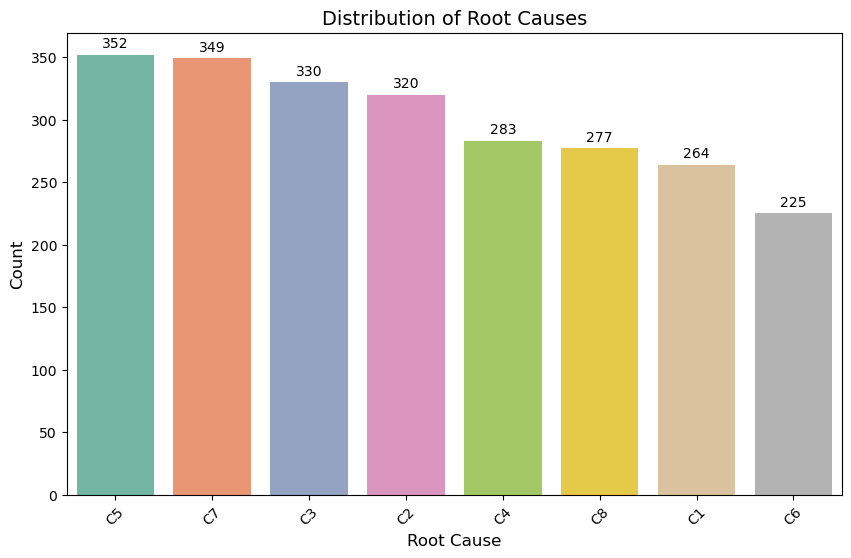

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count root causes
root_cause_counts = ml_df["answer"].value_counts()

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=root_cause_counts.index,
    y=root_cause_counts.values,
    palette="Set2"
)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

# Labels and title
plt.title("Distribution of Root Causes", fontsize=14)
plt.xlabel("Root Cause", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.show()

**Observations**
* C5: Performance degradation due to frequent handovers
* C7: High vehicle speed (>40 km/h) impacting throughput



In [22]:
ml_df.groupby("answer").mean(numeric_only=True).T.round(2)

answer,C1,C2,C3,C4,C5,C6,C7,C8
avg_throughput,735.97,739.74,778.38,735.70,741.56,754.01,739.74,735.58
min_throughput,275.08,282.28,321.04,280.43,281.24,290.77,282.33,276.36
std_throughput,366.88,365.27,324.86,364.36,367.88,370.53,365.39,367.83
low_tp_count,3.96,3.94,3.40,3.96,3.95,3.96,3.95,3.95
low_tp_ratio,0.40,0.39,0.34,0.40,0.39,0.40,0.39,0.40
avg_throughput_low_tp,333.69,338.84,404.98,336.06,337.89,346.54,338.62,332.13
consecutive_low_tp_max,3.96,3.94,3.35,3.95,3.94,3.96,3.95,3.95
max_speed,35.36,35.70,35.65,35.87,35.67,35.56,71.38,35.82
pct_speed_above_40,0.00,0.00,0.00,0.00,0.00,0.00,0.39,0.00
avg_speed_low_tp,19.21,19.52,19.51,19.42,19.33,19.48,59.34,19.51
